In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the dataset
df = pd.read_csv('airbnb_dallas.csv')
print(df.shape)

(48711, 111)


##Question 1: Range and IQR Analysis of Nightly Rate
This question explores the spread and variability of nightly rates across Dallas Airbnb listings. By calculating the range and interquartile range we can understand how pricing is distributed and identify whether extreme outliers are skewing the overall picture.


Range of Nightly Rate: 1899.0
Interquartile Range (IQR): 116.125



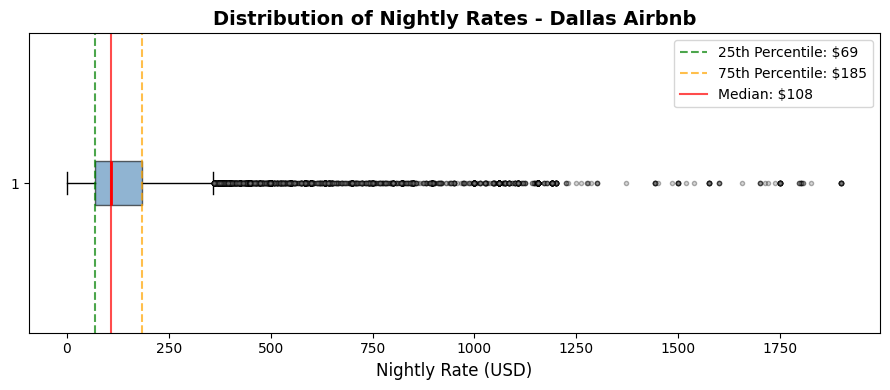

In [ ]:

# Drop missing values in Nightly Rate column
nightly_rate = df['Nightly Rate'].dropna()

# Calculate Range
nightly_range = nightly_rate.max() - nightly_rate.min()

# Calculate Quartiles
Q1 = nightly_rate.quantile(0.25)
Q3 = nightly_rate.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# calculate median
median = nightly_rate.median()

# Print results
print("\nRange of Nightly Rate:", nightly_range)
print("Interquartile Range (IQR):", IQR)

print()

# Create box plot
fig, ax = plt.subplots(figsize=(9, 4))

ax.boxplot(nightly_rate,vert=False,patch_artist=True,
  boxprops=dict(facecolor='steelblue',alpha=0.6),
           medianprops=dict(color='red',
  linewidth=2),flierprops=dict(marker='o',markerfacecolor='gray',
                               markersize=3,
                               alpha=0.3))

ax.set_title('Distribution of Nightly Rates - Dallas Airbnb',
             fontsize=14,
             fontweight='bold')
ax.set_xlabel('Nightly Rate (USD)', fontsize=12)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Add IQR and Range annotations
ax.axvline(x=Q1, color='green',linestyle='--', alpha=0.7,
           label=f'25th Percentile: ${Q1:,.0f}')
ax.axvline(x=Q3, color='orange',linestyle='--', alpha=0.7,
           label=f'75th Percentile: ${Q3:,.0f}')
ax.axvline(x=median, color='red',linestyle='-', alpha=0.7,
           label=f'Median: ${median:,.0f}')

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Question 1: Range & IQR Analysis

The Range of Nightly Rate is 1,899 dollars. After discussing it we realized the range alone is misleading here because a single luxury listing priced at 1,900 dollars per night is enough to inflate the entire spread. This is a known limitation of range as a dispersion measure since it only captures the two extreme values and ignores everything in between. This made us realize why the IQR is a better measure for this dataset.The IQR of 116.12 dollars is a more reliable measure of spread. It tells us that the middle 50% of Dallas Airbnb
listings are priced between 69 dollars and 185.12 dollars per night.

This narrower range of 116.12 dollars compared to the total range of 1,899 dollars reveals that while extreme outliers exist the majority of listings cluster within a moderate price band around the median of 107.50 dollars per night. After analyzing the numbers together we concluded that Dallas has two clearly different pricing segments. The large mainstream market where most hosts price between 69 and 185 dollars per night and a much smaller premium segment where luxury properties command significantly higher nightly rates. The extreme outliers visible in the box plot likely represent large homes or listings in high demand Dallas neighborhoods.

Airbnb should use different pricing strategies for regular and luxury listings. Mainstream hosts should keep prices competitive within the IQR range of 69 to 185 dollars while luxury hosts can charge premium rates supported by stronger marketing and premium listing features.

##Question 2: Descriptive Statistics for Booked Days and Revenue

This question provides a foundational summary of key performance metrics across all listings. By examining the mean, median, standard deviation, minimum, and maximum for booked days and revenue we can understand the overall health and performance of Dallas Airbnb properties.

In [ ]:
# Simple descriptive statistics for both columns
stats = df[['booked_days', 'revenue']].describe()

print("Descriptive Statistics:")
display(stats)

Descriptive Statistics:


,booked_days,revenue
count,31850.000000,31850.000000
mean,25.467598,3134.130926
std,18.774551,4249.338418
min,1.000000,10.000000
25%,10.000000,845.000000
50%,22.000000,2025.000000
75%,37.000000,3919.500000
max,173.000000,134209.000000


Question 2: Descriptive Statistics

The descriptive statistics for booked_days and revenue help explain the overall performance of Airbnb properties in Dallas.

When we looked at the booked days numbers we noticed that the mean of 25.46 days and median of 22 days are fairly close to each other. We felt this suggests most listings follow a relatively consistent booking pattern without too many extreme outliers pulling the average in one direction. The standard deviation of 18.77 days does show moderate variation across listings though. The range from a minimum of 1 day to a maximum of 173 days confirmed that some properties are barely getting any bookings at all while a small number of exceptional performers are booked almost every available day in the period.

Revenue told a very different story. The mean of 3,134 dollars is significantly higher than the median of 2,025 dollars which shows a right skewed distribution. A small number of very high earning listings are pulling the average up. The maximum revenue of 134,209 dollars confirmed this. One more thing striking was that the standard deviation of 4,249 dollars is actually larger than the mean itself. This means earnings are so spread out across Dallas listings that the average alone is almost meaningless as a performance benchmark.

Overall Property Performance:
After discussing the numbers together we identified three key takeaways. First the typical Dallas Airbnb property is booked around 22 days per period and earns roughly 2,025 dollars suggesting moderate performance for most hosts. Second the large gap between mean and median revenue confirms that a small group of top performers earn dramatically more than the majority. Third the high standard deviations for both booked days and revenue tell us that property performance varies enormously across Dallas meaning factors like location, property type, pricing strategy and host quality are likely playing a significant role in separating top performers from the rest.

For Airbnb management this variation shows that not all hosts need the same support. Helping underperforming hosts earn more could improve overall results in Dallas.

##Question 3: Booking Patterns for Superhosts vs Non-Superhosts

This question investigates whether Superhost status has a meaningful impact on booking volume. Understanding how booked days differ between Superhosts and non-Superhosts can reveal the tangible benefits of achieving and maintaining Superhost status on the platform.

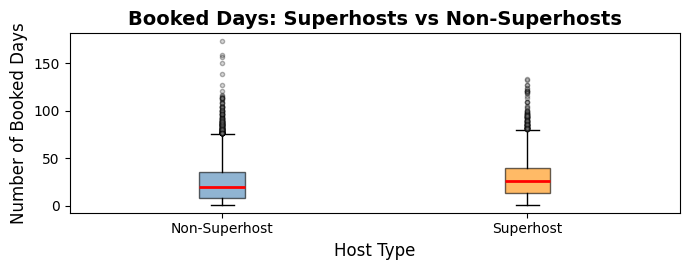

In [ ]:
# Split into two groups
superhosts = df[df['Superhost'] == 1]['booked_days'].dropna()
non_superhosts = df[df['Superhost'] == 0]['booked_days'].dropna()

# Create box plot
fig, ax = plt.subplots(figsize=(7, 2.8))

ax.boxplot([non_superhosts, superhosts],tick_labels=['Non-Superhost',
      'Superhost'], patch_artist=True,boxprops=dict(alpha=0.6),
      medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o',
                markerfacecolor='gray',markersize=3, alpha=0.3))

# Different colors for each box
colors = ['steelblue', 'darkorange']
for patch, color in zip(ax.patches, colors):
    patch.set_facecolor(color)

ax.set_title('Booked Days: Superhosts vs Non-Superhosts',fontsize=14,
    fontweight='bold')
ax.set_xlabel('Host Type', fontsize=12)
ax.set_ylabel('Number of Booked Days', fontsize=12)
ax.set_facecolor('white')
# plt.subplots_adjust(top=0.88)

plt.tight_layout()
plt.show()

Question 3: Superhost Booking Patterns

Visualization Choice:
A box plot was selected because it compares the median, spread, and outliers for both groups more effectively than a bar chart, which would only show averages.

When we placed the two groups side by side the difference was pretty clear. The orange Superhost box sits noticeably higher than the blue non-Superhost box confirming that Superhosts consistently achieve more booked days. Superhosts have a median of 26 days compared to 20 days for non-Superhosts which is a 30 percent higher typical booking rate. The mean followed the same pattern at 28.31 days for Superhosts versus 23.92 days for non-Superhosts confirming this difference holds across the full dataset and is not just driven by outliers.

Both groups have similar standard deviations of around 18.5 to 18.9 days which tells us that booking performance varies equally within each group. However one thing our group found interesting was that non-Superhosts have a higher maximum at 173 days compared to 133 days for Superhosts. After discussing this we think those exceptional non-Superhost listings are likely benefiting from factors like location or unique property features rather than host quality signals like response time or ratings. The box plot also shows significantly more outlier dots above the non-Superhost whisker compared to Superhosts which visually confirms this pattern.

Insights:
Overall, the analysis suggests that Superhost status is strongly associated with higher booking rates. The Superhost badge likely signals trust and quality to guests, leading to more consistent bookings. Airbnb could help non-Superhosts improve bookings by encouraging practices that support earning Superhost status.


##Question 4: Seasonal Patterns in Booking Days for Superhosts

This question examines whether booking activity for Superhosts follows predictable seasonal trends over time. Identifying these patterns can help hosts plan availability and pricing more strategically across different periods of the year.

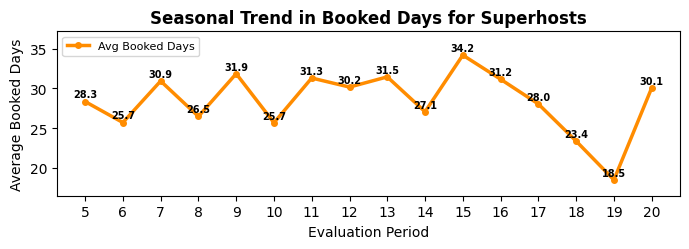

In [ ]:


# Filter Superhosts only
superhosts = df[df['Superhost'] == 1]

# Calculate average booked days per period
period_bookings = superhosts.groupby(
    'superhost_period_all')['booked_days'].mean().reset_index()

# Create line chart
fig, ax = plt.subplots(figsize=(7, 2.6))

ax.plot(period_bookings['superhost_period_all'],
        period_bookings['booked_days'],
    color='darkorange',marker='o',linewidth=2.5,markersize=4,
        label='Avg Booked Days')

# Add value labels on each point
for i, row in period_bookings.iterrows():
    ax.annotate(f"{row['booked_days']:.1f}",
        xy=(row['superhost_period_all'], row['booked_days']),
                xytext=(0, 3),
        textcoords='offset points',ha='center',fontsize=7,
                fontweight='bold')

ax.set_title(
    'Seasonal Trend in Booked Days for Superhosts',
    fontsize=12,
    fontweight='bold'
)
ax.set_xlabel('Evaluation Period', fontsize=10)
ax.set_ylabel('Average Booked Days', fontsize=10)
ax.set_xticks(period_bookings['superhost_period_all'])
ax.legend(loc='upper left', fontsize=8)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# ADD THIS LINE to give space for labels
ax.set_ylim(period_bookings['booked_days'].min() - 2,
            period_bookings['booked_days'].max() + 3)

plt.tight_layout()
plt.show()

Question 4: Seasonal Booking Trends

Visualization Choice:
A line chart was the right choice for this question because we needed to show how average booked days change across multiple evaluation periods. When we discussed the options we agreed that a line chart is the most intuitive way to spot trends and seasonal cycles since the connected data points make it easy to see rises and falls over time.

Trends and Fluctuations:
The first thing our group noticed when looking at the chart was the clear zigzag pattern running from period 5 all the way through to period 17. Booked days consistently alternate between higher and lower periods which we felt strongly suggests a recurring seasonal cycle in Superhost demand rather than random fluctuation.

Higher booking periods occur at periods 7, 9, 11, 13 and 15 with average booked days ranging from 30.9 to 33.9 days. Lower booking periods occur at periods 6, 8, 10, 14 ranging from 25.7 to 26.9 days. The overall peak is period 15 at 34.2 average booked days which was the strongest performing period across the entire dataset.

What surprised our group the most was what happens after period 15. The zigzag pattern breaks completely and booking activity drops sharply and consistently through periods 16, 17, 18 and 19 hitting a low of just 18.5 days at period 19. We discussed this as a group and felt it could reflect a seasonal slowdown or a shift in market conditions during that stretch. The strong recovery back up to 30.1 days at period 20 was encouraging though and suggested the dip was temporary rather than a long term decline.

Implications for Superhosts:
Superhosts could increase prices during high-demand periods and use promotional pricing during weaker periods to maintain booking volume and maximize revenue over time.

##Question 5: Superhost Status and Number of Reviews
This question explores the relationship between Superhost status and guest engagement as measured by the number of reviews received in the past year. Reviews are a key indicator of listing visibility and guest satisfaction on the platform.

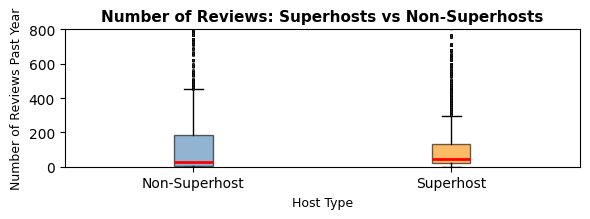

In [ ]:
# Split into two groups
superhosts = df[df['Superhost'] == 1]['numReviews_pastYear'].dropna()
non_superhosts = df[df['Superhost'] == 0][
    'numReviews_pastYear'].dropna()

# Create box plot
fig, ax = plt.subplots(figsize=(6, 2.3))

ax.boxplot(
    [non_superhosts, superhosts],tick_labels=['Non-Superhost',
                                         'Superhost'],
    patch_artist=True,boxprops=dict(alpha=0.6),
    medianprops=dict(color='red',
    linewidth=2),flierprops=dict(marker='o', markerfacecolor='gray',
                    markersize=1, alpha=0.3))

colors = ['steelblue', 'darkorange']
for patch, color in zip(ax.patches, colors):
    patch.set_facecolor(color)

ax.set_title(
    'Number of Reviews: Superhosts vs Non-Superhosts',
    fontsize=11,
    fontweight='bold'
)

ax.set_xlabel('Host Type', fontsize=9)
ax.set_ylabel('Number of Reviews Past Year', fontsize=9)
ax.set_facecolor('white')

ax.set_ylim(0, 800)
plt.tight_layout()
plt.show()

Question 5: Reviews & Superhost Status

Visualization Choice:
A box plot was selected because it clearly compares the median, spread, and outliers of review counts for Superhosts and non-Superhosts.

Comparison:
The data reveals an important distinction between mean
and median reviews for both groups. Superhosts have a
median of 46 reviews per year compared to 27 reviews
for non-Superhosts meaning the typical Superhost
receives more reviews than the typical
non-Superhost. This confirms that Superhost status
is positively associated with higher review activity
from guests. Interestingly, Non-Superhosts show a higher mean number of reviews (240.49) than Superhosts (138.78). This is primarily driven by a few highly popular Non-Superhost listings that accumulate an exceptionally large number of reviews, pulling the average up.
The box plot makes this very clear visually with a large number of outlier dots stretching far above the non-Superhost box reaching all the way up to 3,305 reviews. Superhosts show fewer and less extreme outliers with a maximum of 3,133 reviews.
This is a good example of why median is a more reliable measure than mean when outliers are present.

Impact of Superhost Status:
Overall, the analysis suggests that Superhost status is positively associated with higher review activity for most listings. Increased visibility, guest trust, and stronger search placement likely help Superhosts attract more bookings and reviews over time.

##Question 6: Revenue Distribution by Superhost Status
This question uses a histogram to visualize how revenue is distributed across listings and whether Superhost status creates a meaningful difference in earnings. Understanding this distribution helps identify whether the Superhost label translates into measurable financial benefit.

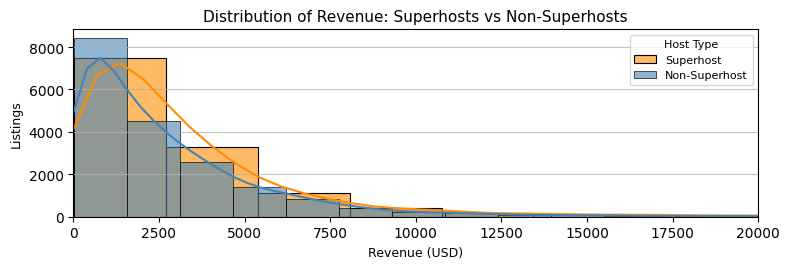

In [ ]:
# Filter data for Superhosts and Non-Superhosts
superhost_revenue = df[df['Superhost'] == 1]['revenue'].dropna()
non_superhost_revenue = df[df['Superhost'] == 0]['revenue'].dropna()

# Create histograms for both groups
plt.figure(figsize=(8, 2.8))
sns.histplot(superhost_revenue, color='darkorange',
             label='Superhost', kde=True, alpha=0.6, bins=50)
sns.histplot(non_superhost_revenue, color='steelblue',
             label='Non-Superhost', kde=True, alpha=0.6, bins=50)

plt.title('Distribution of Revenue: Superhosts vs Non-Superhosts',
          fontsize=11)
plt.xlabel('Revenue (USD)', fontsize=9)
plt.ylabel('Listings', fontsize=9)
plt.legend(title='Host Type', fontsize=8, title_fontsize=8)

# Limit x-axis for better visibility of the main distribution
plt.xlim(0, 20000)


plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

Question 6: Revenue Distribution Histogram

The overlapping histogram effectively
compares the revenue distribution between Superhosts
and non-Superhosts in Dallas. This was the most effective approach because it allows both distributions to be seen simultaneously making it easy to spot differences in shape, spread, and concentration without needing to look at two separate charts.

Skewness:
The first thing our group noticed was that both distributions are strongly right skewed. This means the majority of listings in both groups earn low to moderate revenue while a small number of high earners create a long tail stretching toward 20,000 dollars and beyond. This skewness confirms what we found in Q2 where the mean revenue was significantly higher than the median for the overall dataset. The same pattern holds true when we split by Superhost status.

Spread:
Looking at the curves our group could clearly see a difference in spread between the two groups. The orange Superhost curve is flatter and wider indicating that Superhost revenue is more spread out across a broader range of earnings. The blue non-Superhost curve is taller and much narrower meaning non-Superhost revenue is heavily concentrated at low values. The non-Superhost curve peaks sharply around 500 to 1,000 dollars then drops off quickly while the Superhost curve peaks around 1,000 to 1,500 dollars and declines much more gradually.

Group Differences:
The histogram bars make the difference between the two groups very visible. Non-Superhosts are heavily concentrated in the lowest revenue bin from 0 to 2,500 dollars with approximately 5,000 to 5,200 listings in that range. After 2,500 dollars the non-Superhost bars drop off sharply. Superhosts show a different pattern with around 4,300 listings in the lowest bin but a much slower and more gradual decline across higher revenue ranges. There are noticeably more Superhost listings earning between 2,500 and 10,000 dollars compared to non-Superhosts which confirms that Superhost status is associated with higher and more consistent revenue performance.

Business Insight:
Airbnb should help non-Superhosts improve key quality signals like response times, listing photos, and competitive pricing which could shift their revenue distribution closer to the Superhost pattern and improve overall platform earnings for a large portion of Dallas hosts.

##Question 7: Revenue Before and After Gaining Superhost Status
This question examines whether gaining Superhost status leads to a direct increase in revenue. By comparing average revenue before and after the status change we can assess the real financial impact of becoming a Superhost on the Airbnb platform.

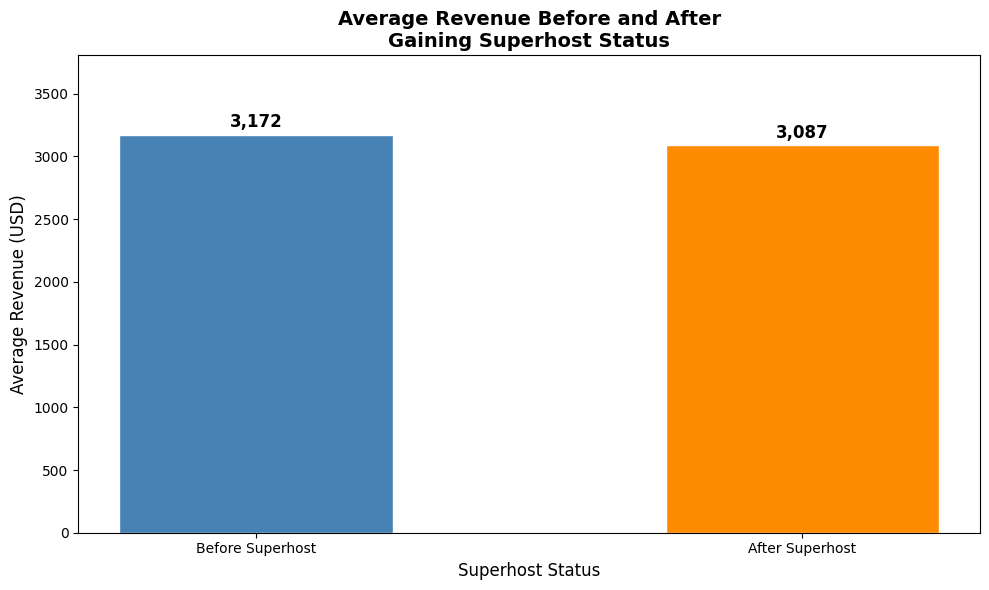

In [ ]:
# Filter hosts who JUST gained Superhost status
gained_superhost = df[df['superhost_change_gain_superhost'] == 1]

# Calculate average revenue before and after
avg_before = gained_superhost['prev_revenue'].dropna().mean()
avg_after = gained_superhost['revenue'].dropna().mean()

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(['Before Superhost', 'After Superhost'],[avg_before,
                                                       avg_after],
    color=['steelblue', 'darkorange'],width=0.5,edgecolor='white')

# Add value labels on top of bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,bar.get_height()
    + 30,f'{bar.get_height():,.0f}',
        ha='center',va='bottom',fontsize=12,fontweight='bold'
    )

ax.set_title(
    'Average Revenue Before and After\nGaining Superhost Status',
    fontsize=14,
    fontweight='bold'
)
ax.set_xlabel('Superhost Status', fontsize=12)
ax.set_ylabel('Average Revenue (USD)', fontsize=12)
ax.set_ylim(0, max(avg_before, avg_after) * 1.2)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

Question 7: Revenue Before vs. After Superhost Status

We used a bar chart to compare average revenue before and after gaining Superhost status.

Findings:
When we first saw the chart our group was surprised. We expected revenue to increase after gaining Superhost status but the data shows a slight decrease from 3,172 dollars before to 3,087 dollars after, a drop of about 85 dollars.

After discussing this we agreed it does not mean Superhost status reduces revenue. This likely captures only the immediate period right after gaining status before hosts have had time to benefit from increased visibility and the trust the badge provides. Revenue benefits probably build up gradually over multiple periods. The 85 dollar difference is also small relative to the standard deviation of 4,249 dollars we found in Q2 suggesting this gap may not be meaningful on its own.

Business Insight:
 Newly qualified Superhosts may not see an immediate revenue boost which could be discouraging. Airbnb should support newly qualified Superhosts with listing optimization tips and increased promotional visibility in their first period after gaining status. This would help accelerate the revenue benefits and encourage long term Superhost retention on the platform.

##Question 8: Revenue Trend Over Time for Superhosts
This question uses a line chart to track how revenue changes across multiple evaluation periods for Superhosts. Analyzing this trend helps us understand whether Superhost status provides sustained revenue growth or only a short term boost.

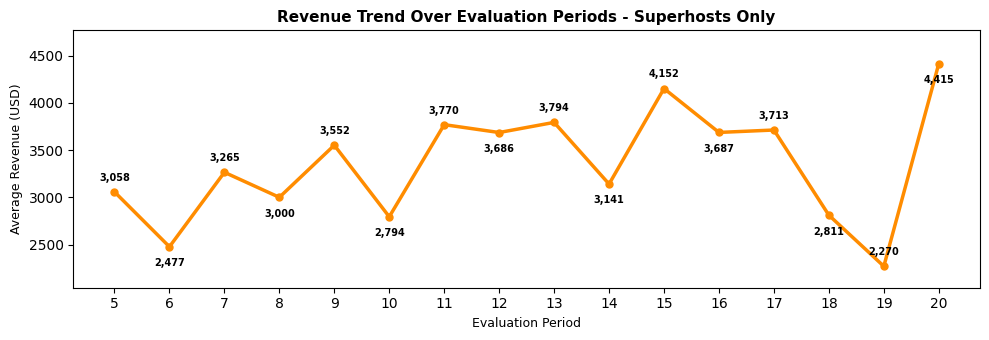

In [ ]:


df = pd.read_csv('airbnb_dallas.csv')

# Filter Superhosts only
superhosts = df[df['Superhost'] == 1]

# Calculate average revenue per period
revenue_trend = superhosts.groupby(
    'superhost_period_all')['revenue'].mean().reset_index()


# Create line chart
fig, ax = plt.subplots(figsize=(10, 3.5))

ax.plot(revenue_trend['superhost_period_all'],
        revenue_trend['revenue'],
        color='darkorange',
    marker='o',linewidth=2.5,markersize=5,label='Superhost Revenue')


for i, row in revenue_trend.iterrows():
    offset = 8 if i % 2 == 0 else -14
    ax.annotate(f"{row['revenue']:,.0f}",
                xy=(row['superhost_period_all'], row['revenue']),
                xytext=(0, offset),
                textcoords='offset points',
                ha='center',
                fontsize=7,
                fontweight='bold')

ax.set_title('Revenue Trend Over Evaluation Periods - Superhosts Only',
    fontsize=11,fontweight='bold')

ax.set_xlabel('Evaluation Period', fontsize=9)
ax.set_ylabel('Average Revenue (USD)', fontsize=9)
ax.set_xticks(revenue_trend['superhost_period_all'])
ax.set_ylim(revenue_trend['revenue'].min() * 0.9,
            revenue_trend['revenue'].max() * 1.08)


ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

Question 8: Revenue Trends Over Time

The overall picture from the chart is that Superhost revenue starts at 3,058 dollars in period 5 and ends at 4,415 dollars in period 20 showing a general upward direction over time despite significant fluctuations along the way.

Looking more closely we noticed a clear zigzag pattern in the earlier periods. Revenue rises from 3,058 at period 5 then dips to 2,477 at period 6 before climbing again to 3,265 at period 7. This alternating pattern continues through periods 7 to 15 with the overall trajectory moving upward. The peak of the entire dataset occurs at period 15 with 3,983 dollars which was the strongest revenue performance across all periods.

Revenue drops sharply and consistently through periods 16, 17, 18 and 19 hitting a low of just 2,270 dollars at period 19. This mirrors the same pattern we observed in Q4 where booked days also dropped significantly around the same periods. This parallel between revenue and bookings both declining together around periods 18 and 19 suggests a genuine seasonal slowdown rather than a random dip. The strong recovery to 4,415 dollars at period 20 confirms this was temporary.

Superhost Impact:
The long term upward trend confirms that maintaining Superhost status is associated with increasing revenue over time as hosts benefit from growing platform visibility stronger guest trust and better search rankings.

Business Insight:
Airbnb should incentivize hosts to maintain Superhost
status across multiple periods as revenue benefits
clearly accumulate over time.

##Question 9: Relationship Between Ratings and Revenue
This question investigates whether higher average ratings translate into higher revenue for Dallas Airbnb listings. A scatter plot allows us to visually examine the strength and direction of this relationship across all properties in the dataset.

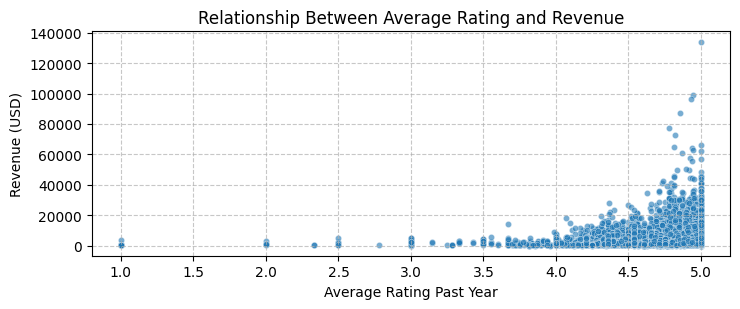

In [ ]:
df = pd.read_csv('airbnb_dallas.csv')

# Drop rows where either 'rating_ave_pastYear' or 'revenue' is NaN
correlation_df = df[['rating_ave_pastYear', 'revenue']].dropna().copy()

plt.figure(figsize=(7.5, 3.2))
sns.scatterplot(x='rating_ave_pastYear', y='revenue',
                data=correlation_df,
                alpha=0.6, s=20)

plt.title('Relationship Between Average Rating and Revenue',
          fontsize=12)
plt.xlabel('Average Rating Past Year', fontsize=10)
plt.ylabel('Revenue (USD)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.subplots_adjust(bottom=0.15)
plt.tight_layout()
plt.show()

# Calculate and print the correlation coefficient
correlation_coefficient = (
    correlation_df['rating_ave_pastYear']
    .corr(correlation_df['revenue']))

Question 9: Ratings & Revenue Relationship

The chart shows almost all listings clustered between
ratings of 4.0 and 5.0 confirming the Dallas market
is dominated by high rated listings. Within this
narrow range revenue varies enormously from near zero
to over 134,000 dollars proving that other factors
beyond ratings such as location property size and
pricing play a much stronger role in determining
revenue. Two listings with nearly identical ratings can have dramatically different revenues depending on other factors. Only a handful of listings fall below 3.5 and they consistently earn near zero revenue confirming that poor ratings are seriously damaging to a listing's performance.

The correlation coefficient of 0.07 confirms a very weak positive relationship between ratings and revenue. This means ratings explain almost none of the variation in revenue across Dallas listings. Our group found this surprising at first but after looking at the scatter plot it made sense. Since almost all listings are already clustered between 4.0 and 5.0 ratings there simply is not enough variation in the rating data to drive meaningful differences in revenue.

Business Insight:
After discussing the findings we concluded that hosts should absolutely maintain ratings above 4.0 to avoid the near zero revenue we saw for poorly rated listings. However once that threshold is met hosts should focus their energy on optimizing location, pricing strategy, and property features rather than obsessing over small improvements in their rating score. For Airbnb management this means rating alone is not a sufficient metric for predicting host success and other factors need to be considered when evaluating listing performance.

##Question 10: Listing Type Composition for Superhost Bookings
This question explores which listing types dominate bookings among Superhosts in Dallas. Understanding the composition of bookings by listing type can help Airbnb identify which property formats are most successful and guide future host recruitment strategies.

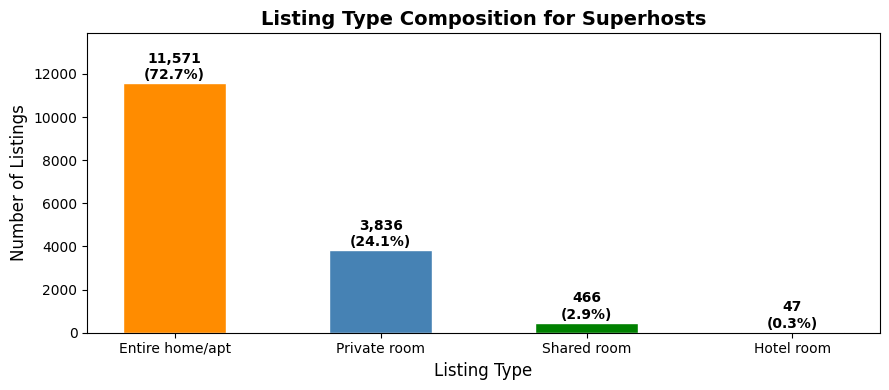

In [ ]:

# Filter Superhosts only
superhosts = df[df['Superhost'] == 1]

# Count listing types
listing_counts = superhosts['Listing Type'].value_counts()
listing_pct = (listing_counts / listing_counts.sum() * 100).round(1)


# Create bar chart
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(listing_counts.index,listing_counts.values,
    color=['darkorange', 'steelblue', 'green', 'purple'],
              width=0.5,edgecolor='white')

# Add value labels on top of bars
for bar, pct in zip(bars, listing_pct):
    ax.text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 50,
        f'{bar.get_height():,}\n({pct}%)',ha='center',va='bottom',
            fontsize=10,
        fontweight='bold')

ax.set_title('Listing Type Composition for Superhosts',
    fontsize=14,fontweight='bold')
ax.set_xlabel('Listing Type', fontsize=12)
ax.set_ylabel('Number of Listings', fontsize=12)
ax.set_ylim(0, listing_counts.max() * 1.2)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

Question 10: Listing Type Composition

Visualization Choice:
A bar chart was selected to visualize the composition of listing types among Superhosts. Our group discussed using a pie chart initially but felt a bar chart was clearer because it makes it much easier to compare the actual numbers across categories especially when one category dominates so heavily.

Findings:
Entire home/apt dominates Superhost bookings with
11,571 listings. Private room is a distant second
with 3,836 listings showing there is still a meaningful segment of Superhosts operating in the shared accommodation space. Shared rooms at 2.9 percent and hotel rooms at just 0.3 percent are almost negligible in the Superhost landscape.

Conclusions:
Entire home listings offer full privacy and control over the environment which aligns naturally with the higher service standards guests expect from Superhost properties. The strong showing of private rooms at 24.1 percent also tells us that budget conscious guests still value Superhost quality even in shared living arrangements suggesting the Superhost badge carries weight across different price points and accommodation styles.

Business Insight:
Airbnb should encourage entire home hosts to pursue and maintain Superhost status, as this category appears to drive the strongest booking performance and likely higher revenue outcomes.

##Question 11: Correlation Matrix of Key Performance Variables
This question uses a heatmap to explore the relationships between revenue, occupancy rate, average rating, and number of reviews. Identifying which variables are most strongly correlated can help hosts and Airbnb management make more informed decisions about where to focus improvement efforts.

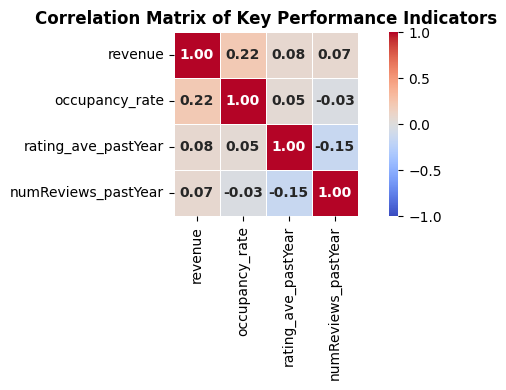

In [ ]:
# Select the four columns
cols = ['revenue', 'occupancy_rate',
        'rating_ave_pastYear', 'numReviews_pastYear']

# Calculate correlation matrix
corr_matrix = df[cols].corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(7, 4))

sns.heatmap(corr_matrix,annot=True,fmt='.2f',cmap='coolwarm',
            center=0,vmin=-1,
    vmax=1,square=True,linewidths=0.5,ax=ax,
            annot_kws={'size': 10, 'weight': 'bold'})

ax.set_title(
    'Correlation Matrix of Key Performance Indicators',
    fontsize=12,fontweight='bold')
plt.tight_layout()
plt.show()

Question 11: Correlation Matrix Heatmap

This question uses a heatmap to explore the relationships
between revenue, occupancy rate, average rating, and number
of reviews.

Interpretation:
The strongest relationship is between revenue and occupancy rate at 0.22. This makes sense as listings booked more frequently naturally earn more. However even this strongest correlation is relatively weak suggesting that nightly pricing and location are playing an even bigger role in determining revenue.

Both rating and number of reviews show very weak correlations with revenue at 0.08 and 0.07. This confirms what we found in Q9 that high ratings or many reviews alone do not strongly predict higher revenue.

One finding which was interesting was the weak negative correlation of -0.15 between rating and number of reviews. We think high volume listings attract more diverse guests which increases the chance of occasional lower ratings pulling the average down slightly.

Business Insights for Hosts:
Hosts should prioritize maximizing occupancy rate
as it shows the strongest link to revenue. Strategies
like competitive pricing instant booking and flexible
minimum stays can help increase occupancy. While
maintaining high ratings is important for visibility
hosts should not expect ratings alone to drive
significant revenue growth.

##Question 12: Neighborhood Revenue and Occupancy for Superhosts
This question analyzes which Dallas neighborhoods generate the highest revenue and occupancy rates among Superhost listings. Understanding geographic performance differences can help Airbnb target host recruitment and marketing efforts more effectively across the city.

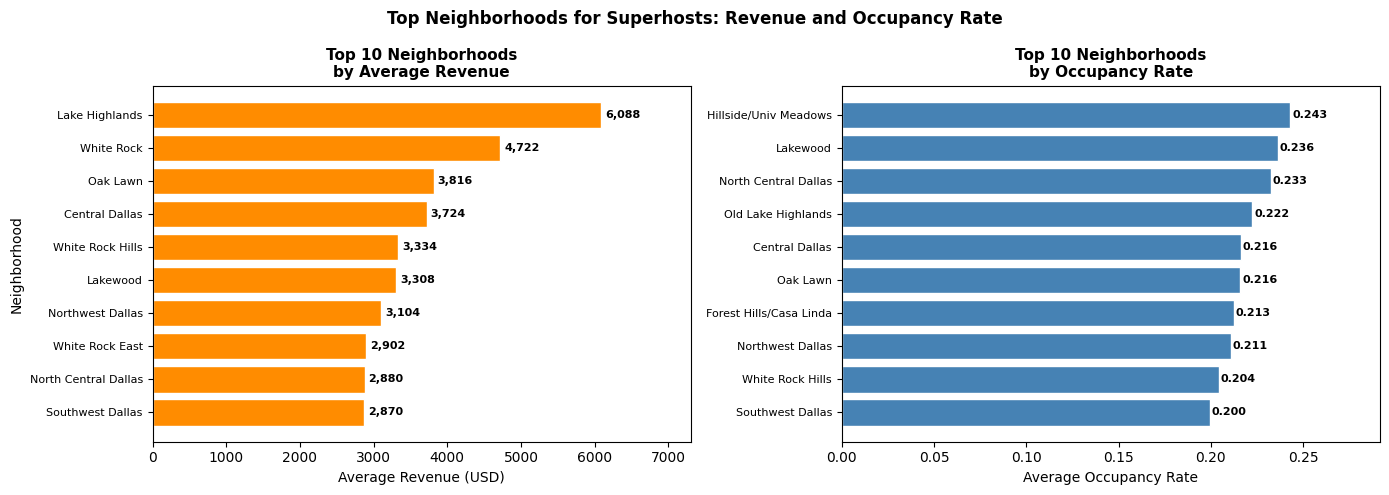

In [ ]:
df = pd.read_csv('airbnb_dallas.csv')
superhosts = df[df['Superhost'] == 1]

neighborhood_stats = superhosts.groupby('Neighborhood').agg(
    Avg_Revenue=('revenue', 'mean'),
    Avg_Occupancy=('occupancy_rate', 'mean'),
    Count=('revenue', 'count')
).reset_index()

neighborhood_stats = neighborhood_stats[neighborhood_stats['Count'] >= 10]
top_revenue = neighborhood_stats.nlargest(10, 'Avg_Revenue')
top_occupancy = neighborhood_stats.nlargest(10, 'Avg_Occupancy')

# Shorten long name
top_occupancy = top_occupancy.copy()
top_occupancy['Neighborhood'] = top_occupancy['Neighborhood'].str.replace(
    'Hillside/University Meadows/Ridge Wood Park/North Stonewall Terrace',
    'Hillside/Univ Meadows', regex=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left panel - Revenue
ax1.barh(top_revenue['Neighborhood'], top_revenue['Avg_Revenue'],
         color='darkorange', edgecolor='white')
ax1.set_title('Top 10 Neighborhoods\nby Average Revenue',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Average Revenue (USD)', fontsize=10)
ax1.set_ylabel('Neighborhood', fontsize=10)
ax1.invert_yaxis()
ax1.set_xlim(0, top_revenue['Avg_Revenue'].max() * 1.2)
ax1.tick_params(axis='y', labelsize=8)
for i, val in enumerate(top_revenue['Avg_Revenue']):
    ax1.text(val + 50, i, f'{val:,.0f}', va='center', fontsize=8, fontweight='bold')

# Right panel - Occupancy
ax2.barh(top_occupancy['Neighborhood'], top_occupancy['Avg_Occupancy'],
         color='steelblue', edgecolor='white')
ax2.set_title('Top 10 Neighborhoods\nby Occupancy Rate',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Average Occupancy Rate', fontsize=10)
ax2.invert_yaxis()
ax2.set_xlim(0, top_occupancy['Avg_Occupancy'].max() * 1.2)
ax2.tick_params(axis='y', labelsize=8)
for i, val in enumerate(top_occupancy['Avg_Occupancy']):
    ax2.text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8, fontweight='bold')

plt.suptitle('Top Neighborhoods for Superhosts: Revenue and Occupancy Rate',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Question 12: Neighborhood Revenue & Occupancy Analysis

Visualization Choice:
We chose a side by side horizontal bar chart to display both revenue and occupancy rankings simultaneously. The horizontal bars work better here because neighborhood names are long and would overlap on a vertical chart. Having both panels next to each other also makes it easy to spot which neighborhoods appear in both lists and which only excel in one dimension.

Revenue Findings:
Lake Highlands is the top performing neighborhood for
Superhost revenue at 6,088 dollars per period almost
30 percent higher than the second ranked White Rock
at 4,722 dollars. Oak Lawn and Central Dallas follow
at 3,816 and 3,724 dollars respectively. These
neighborhoods likely benefit from proximity to
Dallas attractions business districts and strong
local demand.

Occupancy Findings:
The occupancy rankings told a different story.
Hillside University Meadows leads with an occupancy
rate of 0.24 followed by Lakewood at 0.236 and
North Central Dallas at 0.233. Notably Lake Highlands
which tops revenue does not appear in the top 3 for
occupancy suggesting it generates high revenue
through higher nightly rates rather than frequency
of bookings.

Overlapping Neighborhoods:
Several neighborhoods appear in both top 10 lists
including Central Dallas, Oak Lawn, Northwest Dallas,
White Rock Hills and Southwest Dallas. These
neighborhoods represent the most well rounded
markets offering both strong revenue and consistent
occupancy rates for Superhosts.

Business Insight:
After looking at both charts together we concluded that Airbnb should tailor its strategy based on neighborhood type. Lake Highlands and White Rock should be targeted for revenue maximization campaigns while Hillside University Meadows and Lakewood are better targets for occupancy optimization efforts. New hosts entering the Dallas market should consider neighborhoods that appear in both lists like Central Dallas and Oak Lawn as these offer the best overall balance of revenue and occupancy performance for Superhosts.

##Question 13: Superhost Status and Nightly Rates Pricing Strategy

This question explores whether Superhost status influences the pricing strategy, specifically focusing on the 'Nightly Rate'. Understanding this relationship can help hosts optimize their pricing and guests understand potential value.

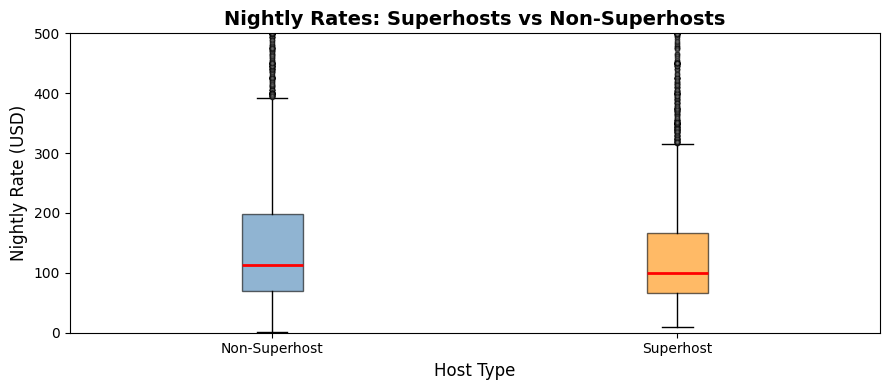

In [ ]:
# Filter data for Superhosts and Non-Superhosts
superhost_nightly_rate =(df[df['Superhost'] == 1]
 ['Nightly Rate'].dropna())
non_superhost_nightly_rate = (
    df[df['Superhost'] == 0]['Nightly Rate'].dropna())

# Create a box plot to visualize the distributions
fig, ax = plt.subplots(figsize=(9, 4))

ax.boxplot(
    [non_superhost_nightly_rate, superhost_nightly_rate],
    tick_labels=['Non-Superhost', 'Superhost'],
    patch_artist=True,boxprops=dict(alpha=0.6),
    medianprops=dict(color='red',
    linewidth=2),flierprops=dict(marker='o', markerfacecolor='gray',
                    markersize=3, alpha=0.3))

# Assign different colors to each box
colors = ['steelblue', 'darkorange']
for patch, color in zip(ax.patches, colors):
    patch.set_facecolor(color)

ax.set_title(
    'Nightly Rates: Superhosts vs Non-Superhosts',fontsize=14,
    fontweight='bold')
ax.set_xlabel('Host Type', fontsize=12)
ax.set_ylabel('Nightly Rate (USD)', fontsize=12)

# Limit y-axis for better visibility of the main distribution
ax.set_ylim(0, 500)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()



Question 13: Pricing Strategy & Superhost Status

Visualization Choice:
A box plot was used because it clearly compares the distribution, median, spread, and outliers of nightly rates for Superhosts and non-Superhosts.

Findings:
We assumed Superhosts would charge higher rates because of their trusted status but the data shows non-Superhosts actually have a higher median nightly rate at 112.50 dollars compared to 100.00 dollars for Superhosts. Looking at the box plot the blue non-Superhost box sits noticeably higher than the orange Superhost box confirming this pattern visually. Non-Superhosts also show much greater price variability with a standard deviation of 182.45 dollars compared to 138.83 dollars for Superhosts. This means non-Superhost pricing is more spread out and inconsistent across listings while Superhosts cluster more tightly around a moderate competitive price range.

Pricing Strategy Analysis:
After discussing this as a group we concluded that Superhosts appear to follow a deliberate strategy of competitive and consistent pricing. Since Superhost status requires maintaining high booking rates and strong guest ratings Superhosts likely keep their prices moderate to ensure steady demand and consistent occupancy. Charging too much could reduce bookings and threaten their Superhost qualification. Non-Superhosts without this constraint price more aggressively or inconsistently which results in higher average rates but likely lower and less predictable occupancy as we confirmed in Q3 where Superhosts had a 30 percent higher median booking rate.
This connects back to what we found in Q7 and Q8 as well. Superhosts earn stronger revenue over time not by charging the highest nightly rate but by maintaining consistent bookings across multiple periods through competitive pricing and quality service.

Business Insight:
Airbnb should encourage non-Superhosts to adopt more competitive and stable pricing strategies similar to Superhosts, since moderate pricing combined with quality service appears to drive stronger occupancy and long-term revenue growth.

##Question 14: Impact of 5-Star Reviews on Revenue Generation
This question examines what the number of 5-star reviews reveals about revenue generation across Dallas listings. By analyzing this relationship we can determine whether review quality and volume are meaningful drivers of financial performance for Airbnb hosts.

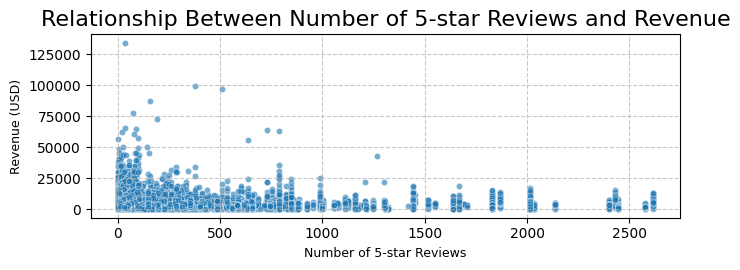

In [ ]:
# Drop rows where either 'numReviews_5star' or 'revenue' is NaN
correlation_df = (df[['num_5_star_Rev_pastYear', 'revenue']].dropna()
.copy())

# Create a scatter plot to visualize the relationship
plt.figure(figsize=(7, 2.8))
sns.scatterplot(x='num_5_star_Rev_pastYear', y='revenue',
                data=correlation_df, alpha=0.6, s=20)

plt.title('Relationship Between Number of 5-star Reviews and Revenue',
          fontsize=16)
plt.xlabel('Number of 5-star Reviews', fontsize=9)
plt.ylabel('Revenue (USD)', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.subplots_adjust(bottom=0.15)
plt.tight_layout()
plt.show()

# Calculate and print the correlation coefficient
correlation_coefficient = (
 correlation_df['num_5_star_Rev_pastYear']
  .corr(correlation_df['revenue']))


Question 14: 5-Star Reviews & Revenue

Visualization:
The scatter plot demonstrates the relationship between the number of 5-star reviews and revenue across 26,809 Dallas Airbnb listings. The x-axis shows review count and the y-axis shows revenue in USD.

Scatter Plot Interpretation:
The first thing we noticed when looking at the chart was how heavily concentrated the data is on the left side between 0 and 500 reviews. The vast majority of Dallas listings fall within this range and revenue within this cluster varies enormously from near zero all the way up to 134,209 dollars. This wide vertical spread at low review counts immediately told us that review volume alone is not driving revenue differences.

The highest earning listings actually appear at low to moderate review counts rather than at the high end of the x-axis. As review count increases beyond 500 the data becomes very sparse and revenue levels off at lower and more consistent values. Listings with over 1,500 reviews are rarely earning above 20,000 dollars which we found counterintuitive at first but makes sense when you consider that high review volume simply reflects a long booking history not necessarily a premium priced property.

Correlation Analysis:
The correlation coefficient of 0.084 confirms there is almost no linear relationship between 5-star review count and revenue.

Business Insight:
Dallas hosts should not rely on accumulating 5-star reviews to grow revenue. Pricing strategy, property type, and neighborhood are much stronger revenue drivers. Airbnb should focus host education on pricing optimization rather than simply encouraging more reviews.

##Question 15: Story of Place - The Role of Location in Pricing and Bookings
This question uses neighborhood-level data to tell a story of place across Dallas Airbnb listings. By examining how location influences nightly pricing, revenue, and occupancy we can present actionable geographic insights to Airbnb management for strategic decision making.


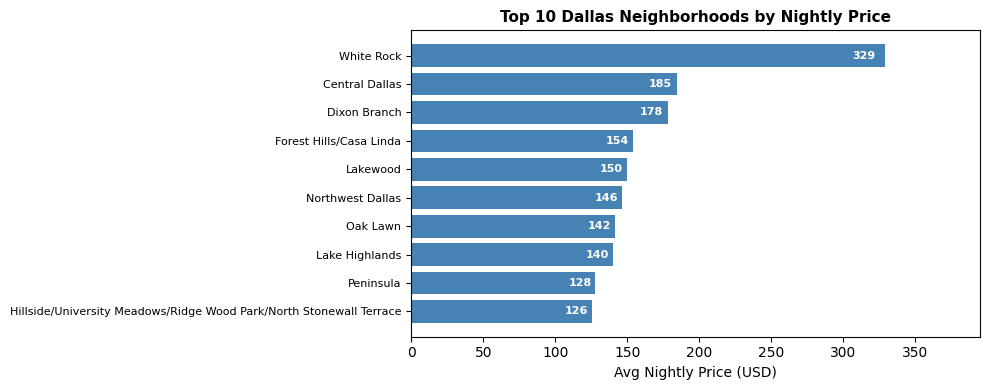

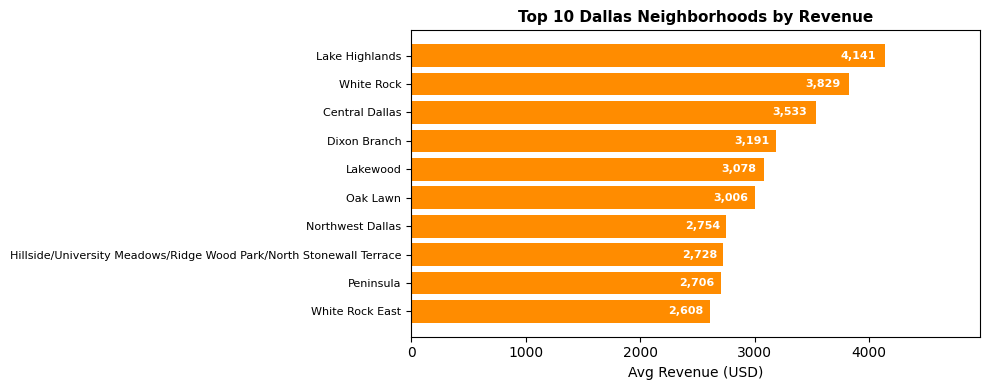

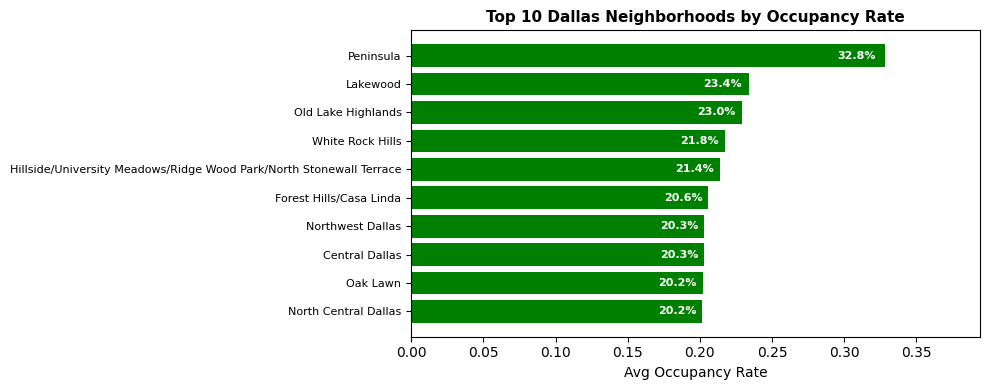

In [ ]:

neighborhood_stats = df.groupby('Neighborhood').agg(
    avg_price=('Nightly Rate', 'mean'),
    avg_revenue=('revenue', 'mean'),
    avg_occupancy=('occupancy_rate', 'mean'),
    total_bookings=('booked_days', 'sum'),
    listing_count=('Airbnb Property ID', 'count')
).reset_index()

top10_price = neighborhood_stats.sort_values('avg_price', ascending=False).head(10)
top10_rev = neighborhood_stats.sort_values('avg_revenue', ascending=False).head(10)
top10_occ = neighborhood_stats.sort_values('avg_occupancy', ascending=False).head(10)

# Chart 1 - Price
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.barh(top10_price['Neighborhood'], top10_price['avg_price'], color='steelblue')
ax1.set_xlabel('Avg Nightly Price (USD)', fontsize=10)
ax1.set_title('Top 10 Dallas Neighborhoods by Nightly Price', fontsize=11, fontweight='bold')
ax1.invert_yaxis()
ax1.tick_params(axis='y', labelsize=8)
ax1.set_xlim(0, top10_price['avg_price'].max() * 1.2)
for i, v in enumerate(top10_price['avg_price']):
    ax1.text(v * 0.98, i, f'{v:,.0f}', va='center', ha='right',
             fontsize=8, color='white', fontweight='bold')
plt.tight_layout()
plt.show()
plt.close('all')

# Chart 2 - Revenue
fig, ax2 = plt.subplots(figsize=(10, 4))
ax2.barh(top10_rev['Neighborhood'], top10_rev['avg_revenue'], color='darkorange')
ax2.set_xlabel('Avg Revenue (USD)', fontsize=10)
ax2.set_title('Top 10 Dallas Neighborhoods by Revenue', fontsize=11, fontweight='bold')
ax2.invert_yaxis()
ax2.tick_params(axis='y', labelsize=8)
ax2.set_xlim(0, top10_rev['avg_revenue'].max() * 1.2)
for i, v in enumerate(top10_rev['avg_revenue']):
    ax2.text(v * 0.98, i, f'{v:,.0f}', va='center', ha='right',
             fontsize=8, color='white', fontweight='bold')
plt.tight_layout()
plt.show()
plt.close('all')

# Chart 3 - Occupancy
fig, ax3 = plt.subplots(figsize=(10, 4))
ax3.barh(top10_occ['Neighborhood'], top10_occ['avg_occupancy'], color='green')
ax3.set_xlabel('Avg Occupancy Rate', fontsize=10)
ax3.set_title('Top 10 Dallas Neighborhoods by Occupancy Rate', fontsize=11, fontweight='bold')
ax3.invert_yaxis()
ax3.tick_params(axis='y', labelsize=8)
ax3.set_xlim(0, top10_occ['avg_occupancy'].max() * 1.2)
for i, v in enumerate(top10_occ['avg_occupancy']):
    ax3.text(v * 0.98, i, f'{v:.1%}', va='center', ha='right',
             fontsize=8, color='white', fontweight='bold')
plt.tight_layout()
plt.show()
plt.close('all')



Question 15: Story of Place Analysis

Visualization Choice:
We used three separate horizontal bar charts to show the top 10 neighborhoods across three dimensions: average nightly price, average revenue, and average occupancy rate. Separating these into three charts made the story clearer because each metric tells a different part of the location story and combining them would have made the visual too cluttered to read easily.

Chart 1 - Pricing Story:
White Rock commands the highest average nightly rate at 329 USD per night which is nearly double Central Dallas at 185 USD and far above every other neighborhood. What stood out was how much of an outlier White Rock is compared to the rest of the top 10. Dixon Branch at 178 USD and Forest Hills at 154 USD also achieve above average pricing suggesting that proximity to natural amenities and quieter residential areas supports stronger nightly rates. Location is clearly giving certain neighborhoods significant pricing power that others simply cannot match.

Chart 2 - Revenue Story:
Despite not having the highest nightly rate Lake Highlands leads all neighborhoods in average revenue at 4,141 USD per listing. White Rock follows at 3,829 USD and Central Dallas at 3,533 USD. This was a key insight for us because it shows that high nightly price does not always equal high revenue.

Chart 3 - Occupancy Story:
Peninsula stands apart with an occupancy rate of 32.8 percent, significantly higher than all other neighborhoods. Lakewood at 23.4 percent and Old Lake Highlands at 23.0 percent follow. These neighborhoods likely benefit from proximity to White Rock Lake and community-oriented environments that attract leisure travelers seeking a neighborhood experience rather than a hotel-like stay.

Strategic Implications for Airbnb Management:
Dallas does not have one winning neighborhood. It has three types of winners. White Rock wins on price. Lake Highlands wins on revenue. Peninsula wins on bookings and occupancy. Airbnb management should present location-specific benchmarks to hosts so they can set realistic pricing expectations based on their neighborhood. Recruitment efforts should prioritize Lake Highlands and Peninsula as high-opportunity markets. Additionally, underperforming neighborhoods should be analyzed against these top performers to identify gaps in pricing strategy and listing quality that targeted support could help close.


##Question 16: Management Recommendation for Airbnb Dallas
This question asks us to step into the role of Airbnb's management team and propose one data-driven change to improve platform performance. Our recommendation is supported by evidence from the dataset, justified through a clear KPI, and accompanied by a discussion of the trade-offs Airbnb should carefully consider before implementation.

Question 16: Management Recommendation & KPI Justification

Proposed Change:
Airbnb should build a neighborhood based pricing guidance tool that shows hosts personalized pricing recommendations based on what is actually working in their specific area of Dallas.

Evidence from the Dataset:
After going through all the data our group kept coming back to one thing. Location makes a huge difference in how much hosts earn but most hosts do not seem to know how to price for their specific neighborhood.

When we looked at the numbers White Rock had the highest nightly rate at 329 USD but Lake Highlands was making more total revenue at 4,141 USD average per listing with a nightly rate of only 140 USD. That was genuinely surprising to us. It means charging more per night does not always mean earning more. Peninsula was another interesting case with the highest occupancy at 32.8 percent but one of the lowest nightly rates at 128 USD. Those hosts are clearly in high demand but they are leaving significant revenue on the table by underpricing.

The revenue distribution data from Q2 also supports this. The median revenue was only 2,025 USD while the mean was 3134.13 USD confirming that most hosts are earning well below what top performers in their own neighborhoods are achieving. This gap exists largely because hosts lack neighborhood specific pricing intelligence.

KPI Justification:
We picked average revenue per listing by neighborhood as our primary KPI because it captures both pricing and booking volume together in one number. Current data shows a wide gap from 4,141 USD in Lake Highlands down to under 2,000 USD in lower performing areas. Closing this gap through better pricing guidance would raise platform wide revenue and improve host satisfaction. Occupancy rate would serve as a secondary KPI to ensure price increases are not reducing bookings in high demand areas like Peninsula.

Trade-offs:
Hosts care a lot about setting their own prices so Airbnb should make this tool optional and frame it as helpful data not a requirement. There is also a risk that pushing prices up in affordable high occupancy neighborhoods could discourage budget travelers and reduce overall bookings. Building the tool also costs money so the return on investment would need to be clear before moving forward.

Despite these trade-offs our group felt the neighborhood data makes a strong case for this recommendation. It is practical, directly supported by the dataset, and targets the most actionable opportunity we found across the entire Dallas market analysis.